In [1]:
# ============================================
# CSE-4155 Introduction to Machine Learning
# Lab 01 - Linear Regression with Gradient Descent
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For reproducible synthetic data
np.random.seed(42)

In [2]:
# ============================================
# 1. GENERATE SYNTHETIC DATA
# ============================================

def generate_synthetic_data(n=100, intercept=3, slope=5, seed=42):
    """
    Generate synthetic data using:

        y = intercept + slope*x + noise

    where:
        x = 1, 2, ..., 100
        noise ~ N(0, 1)
    """

    np.random.seed(seed)

    # Generate x values from 1 to 100
    x = np.arange(1, n + 1, dtype=float)

    # Generate standard Gaussian noise
    noise = np.random.normal(0, 1, n)

    # Generate y values
    y = intercept + slope * x + noise

    return x, y

In [3]:
# ============================================
# 2. GENERATE SYNTHETIC DATA
# ============================================

x_syn, y_syn = generate_synthetic_data()

print("Number of samples:", len(x_syn))

print("\nFirst 10 x values:")
print(x_syn[:10])

print("\nFirst 10 y values:")
print(y_syn[:10])

Number of samples: 100

First 10 x values:
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]

First 10 y values:
[ 8.49671415 12.8617357  18.64768854 24.52302986 27.76584663 32.76586304
 39.57921282 43.76743473 47.53052561 53.54256004]


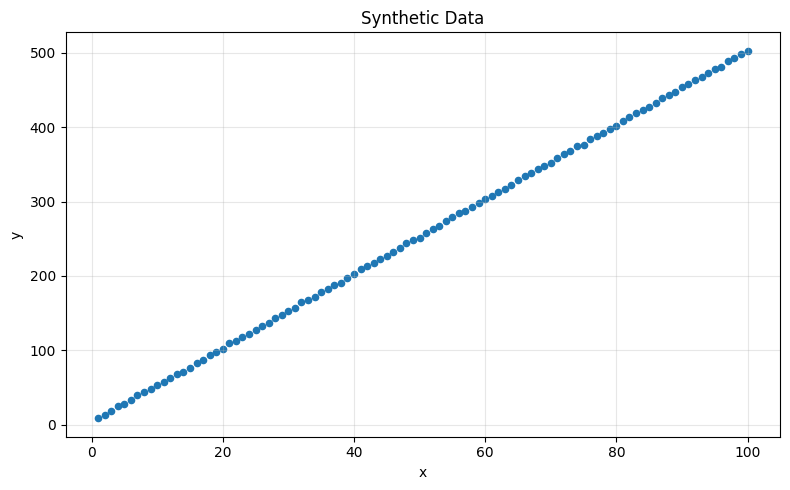

In [4]:
# ============================================
# 3. PLOT SYNTHETIC DATA
# ============================================

plt.figure(figsize=(8, 5))

plt.scatter(x_syn, y_syn, s=20)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Data")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [5]:
# ============================================
# 4. SAVE SYNTHETIC DATA
# ============================================

def save_data(filename, x, y):
    """
    Save x and y values to a CSV file.
    """

    data = pd.DataFrame({
        "x": x,
        "y": y
    })

    data.to_csv(filename, index=False)

    print(f"Data saved to {filename}")

In [6]:
# Save according to the lab requirement
save_data("lab01_data.csv", x_syn, y_syn)

Data saved to lab01_data.csv


In [7]:
# ============================================
# 5. LOAD DATA
# ============================================

def load_data(filename, has_header=True):
    """
    Load x and y data from a CSV file.

    Parameters:
        filename    : CSV file name
        has_header  : True if CSV has column names,
                      False if it does not

    Returns:
        x : feature values
        y : target values
    """

    if has_header:
        data = pd.read_csv(filename)
    else:
        # The supplied data_01.csv has no header
        data = pd.read_csv(
            filename,
            header=None,
            names=["x", "y"]
        )

    # Convert values to float
    x = data["x"].values.astype(float)
    y = data["y"].values.astype(float)

    return x, y

In [8]:
# ============================================
# 6. PROCESS DATA
# ============================================

def process_data(x, y, feature_scaling=False):
    """
    Prepare data for linear regression.

    Steps:
        1. Optionally scale x
        2. Add dummy feature x0 = 1

    Returns:
        X              : design matrix
        y              : target vector
        scale_params   : information needed to
                         return to original x scale
    """

    # Make copies so original data is not changed
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Scaling parameters
    scale_params = {
        "scaled": feature_scaling,
        "mean": 0.0,
        "std": 1.0
    }

    # Start with original x
    x_processed = x.copy()

    # ----------------------------------------
    # Feature scaling
    # ----------------------------------------

    if feature_scaling:

        mean = np.mean(x)
        std = np.std(x)

        x_processed = (x - mean) / std

        scale_params["mean"] = mean
        scale_params["std"] = std

    # ----------------------------------------
    # Add dummy feature x0 = 1
    # ----------------------------------------

    X = np.column_stack((
        np.ones(len(x)),
        x_processed
    ))

    return X, y, scale_params

In [9]:
# ============================================
# 7. COMPUTE COST
# ============================================

def compute_cost(X, y, theta):
    """
    Compute the cost function:

        J(theta) = 1/(2m) * sum((Xtheta - y)^2)
    """

    m = len(y)

    # Predictions
    predictions = X.dot(theta)

    # Errors
    errors = predictions - y

    # Cost
    cost = (1 / (2 * m)) * np.sum(errors ** 2)

    return cost

In [10]:
# ============================================
# 8. GRADIENT DESCENT
# ============================================

def gradient_descent(X, y, theta, learning_rate, iterations):
    """
    Perform batch gradient descent.

    Returns:
        theta        : learned parameters
        cost_history : cost after every iteration
    """

    m = len(y)

    # Store cost at every iteration
    cost_history = []

    for i in range(iterations):

        # ------------------------------------
        # 1. Calculate predictions
        # ------------------------------------
        predictions = X.dot(theta)

        # ------------------------------------
        # 2. Calculate errors
        # ------------------------------------
        errors = predictions - y

        # ------------------------------------
        # 3. Calculate gradient
        # ------------------------------------
        gradient = (1 / m) * X.T.dot(errors)

        # ------------------------------------
        # 4. Update theta
        # ------------------------------------
        theta = theta - learning_rate * gradient

        # ------------------------------------
        # 5. Calculate cost
        # ------------------------------------
        cost = compute_cost(X, y, theta)

        cost_history.append(cost)

    return theta, cost_history

In [11]:
# ============================================
# 9. TRAIN
# ============================================

def train(X, y, learning_rate=0.01, iterations=1000):
    """
    Train linear regression using gradient descent.
    """

    # Number of parameters
    n = X.shape[1]

    # Initialize theta with zeros
    theta = np.zeros(n)

    # Run gradient descent
    theta, cost_history = gradient_descent(
        X,
        y,
        theta,
        learning_rate,
        iterations
    )

    return theta, cost_history

In [12]:
# ============================================
# 10. EVALUATE
# ============================================

def evaluate(X, y, theta):
    """
    Evaluate the trained linear regression model.

    Returns:
        predictions
        cost
    """

    # Calculate predictions
    predictions = X.dot(theta)

    # Calculate final cost
    cost = compute_cost(X, y, theta)

    print(f"Final Cost = {cost:.6f}")

    # ----------------------------------------
    # R^2 is not used for now because it has
    # not been taught in the lab yet.
    # ----------------------------------------
    #
    # ss_res = np.sum((y - predictions) ** 2)
    # ss_tot = np.sum((y - np.mean(y)) ** 2)
    # r2 = 1 - (ss_res / ss_tot)
    # print(f"R^2 = {r2:.6f}")
    #
    # ----------------------------------------

    return predictions, cost

In [13]:
# ============================================
# 11. PLOT DATA
# ============================================

def plot_data(x, y, title="Dataset"):
    """
    Plot the data points.
    """

    plt.figure(figsize=(8, 5))

    plt.scatter(
        x,
        y,
        s=20,
        alpha=0.7
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)

    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.show()

In [14]:
# ============================================
# 12. PLOT COST HISTORY
# ============================================

def plot_cost_history(cost_history, title="Training Error Curve"):
    """
    Plot cost against number of iterations.
    """

    plt.figure(figsize=(8, 5))

    plt.plot(
        range(1, len(cost_history) + 1),
        cost_history
    )

    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title(title)

    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.show()

In [39]:
# ============================================
# 13. PLOT REGRESSION LINE
# ============================================

def plot_regression_line(
    x,
    y,
    theta,
    scale_params,
    title="Regression Line"
):
    """
    Plot the data points and learned regression line.

    The x-axis is kept in the original scale,
    even when feature scaling was used.
    """

    plt.figure(figsize=(8, 5))

    # Plot original data
    plt.scatter(
        x,
        y,
        s=20,
        alpha=0.7,
        label="Data Points"
    )

    # ----------------------------------------
    # Create smooth x values for line
    # ----------------------------------------

    x_line = np.linspace(
        x.min(),
        x.max(),
        300
    )

    # ----------------------------------------
    # Apply the same scaling used during
    # training
    # ----------------------------------------

    if scale_params["scaled"]:

        x_line_processed = (
            x_line - scale_params["mean"]
        ) / scale_params["std"]

    else:

        x_line_processed = x_line

    # ----------------------------------------
    # Add dummy feature
    # ----------------------------------------

    X_line = np.column_stack((
        np.ones(len(x_line)),
        x_line_processed
    ))

    # ----------------------------------------
    # Calculate line predictions
    # ----------------------------------------

    y_line = X_line.dot(theta)

    # ----------------------------------------
    # Plot learned line
    # ----------------------------------------

    plt.plot(
        x_line,
        y_line,
        color="red",
        linewidth=2,
        label="Learned Regression Line"
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)

    plt.legend()

    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.show()

In [40]:
# ============================================
# 14. PRINT PARAMETERS
# ============================================

def print_parameters(theta, scale_params):
    """
    Print learned model parameters.

    If scaling was used, also convert the
    parameters back to the original x scale.
    """

    print("=" * 50)
    print("LEARNED MODEL PARAMETERS")
    print("=" * 50)

    print(f"theta_0 = {theta[0]:.6f}")
    print(f"theta_1 = {theta[1]:.6f}")

    # ----------------------------------------
    # Convert back to original x scale
    # ----------------------------------------

    if scale_params["scaled"]:

        mean = scale_params["mean"]
        std = scale_params["std"]

        original_slope = theta[1] / std

        original_intercept = (
            theta[0]
            - (theta[1] * mean / std)
        )

        print("\nOriginal x scale:")
        print(f"Intercept = {original_intercept:.6f}")
        print(f"Slope     = {original_slope:.6f}")

        print("\nOriginal-scale equation:")
        print(
            f"y_hat = {original_intercept:.6f}"
            f" + ({original_slope:.6f})x"
        )

    else:

        print("\nEquation:")
        print(
            f"y_hat = {theta[0]:.6f}"
            f" + ({theta[1]:.6f})x"
        )

    print("=" * 50)

In [41]:
# ============================================
# PART A - SYNTHETIC DATA
# ============================================

x_syn, y_syn = load_data(
    "lab01_data.csv",
    has_header=True
)

print("Synthetic dataset loaded.")
print("Number of samples:", len(x_syn))

Synthetic dataset loaded.
Number of samples: 100


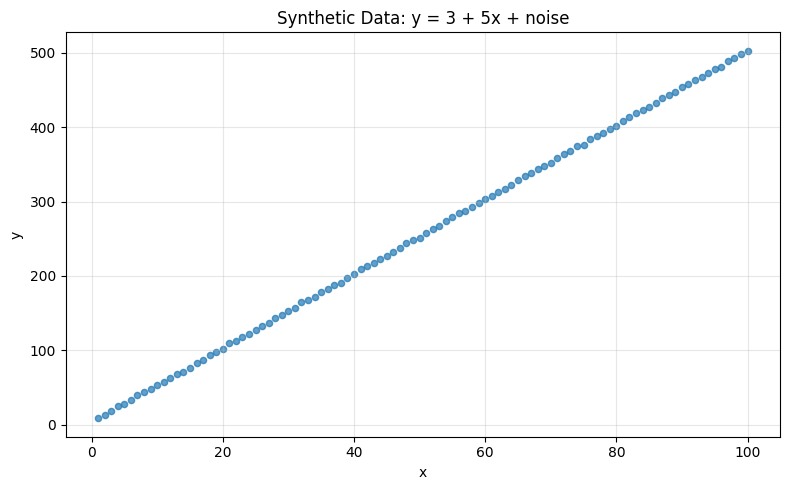

In [42]:
plot_data(
    x_syn,
    y_syn,
    title="Synthetic Data: y = 3 + 5x + noise"
)

In [43]:
# ============================================
# PART A - WITHOUT FEATURE SCALING
# ============================================

X_syn_raw, y_syn_raw, params_syn_raw = process_data(
    x_syn,
    y_syn,
    feature_scaling=False
)

# Try different learning rates
learning_rates = [
    0.000001,
    0.00001,
    0.0001
]

print("Learning-rate experiment:")
print()

for lr in learning_rates:

    theta_test, cost_test = train(
        X_syn_raw,
        y_syn_raw,
        learning_rate=lr,
        iterations=5000
    )

    final_cost = cost_test[-1]

    print(
        f"Learning rate = {lr:<10} "
        f"Final cost = {final_cost:.6f}"
    )

Learning-rate experiment:

Learning rate = 1e-06      Final cost = 1.336723
Learning rate = 1e-05      Final cost = 1.316357
Learning rate = 0.0001     Final cost = 1.135703


In [44]:
# ============================================
# SYNTHETIC DATA - FEATURE SCALING
# ============================================

X_syn, y_syn, scale_params_syn = process_data(
    x_syn,
    y_syn,
    feature_scaling=True
)

print("Synthetic data processed.")

print("\nFirst 5 rows of X:")
print(X_syn[:5])

Synthetic data processed.

First 5 rows of X:
[[ 1.         -1.71481604]
 [ 1.         -1.68017329]
 [ 1.         -1.64553055]
 [ 1.         -1.6108878 ]
 [ 1.         -1.57624505]]


In [45]:
# ============================================
# TRAIN SYNTHETIC MODEL
# ============================================

theta_syn, cost_history_syn = train(
    X_syn,
    y_syn,
    learning_rate=0.01,
    iterations=1000
)

print("Training completed.")

Training completed.


In [46]:
# ============================================
# EVALUATE SYNTHETIC MODEL
# ============================================

predictions_syn, final_cost_syn = evaluate(
    X_syn,
    y_syn,
    theta_syn
)

print_parameters(
    theta_syn,
    scale_params_syn
)

Final Cost = 0.407533
LEARNED MODEL PARAMETERS
theta_0 = 255.385128
theta_1 = 144.364336

Original x scale:
Intercept = 2.825672
Slope     = 5.001177

Original-scale equation:
y_hat = 2.825672 + (5.001177)x


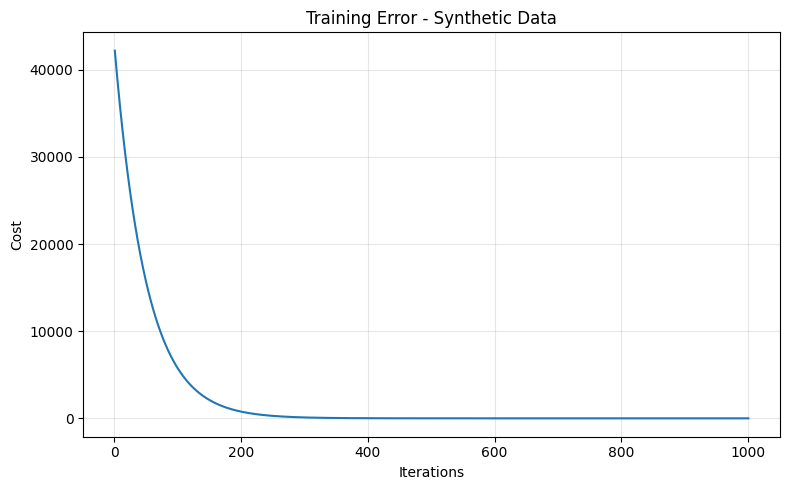

In [47]:
# ============================================
# SYNTHETIC - TRAINING ERROR
# ============================================

plot_cost_history(
    cost_history_syn,
    title="Training Error - Synthetic Data"
)

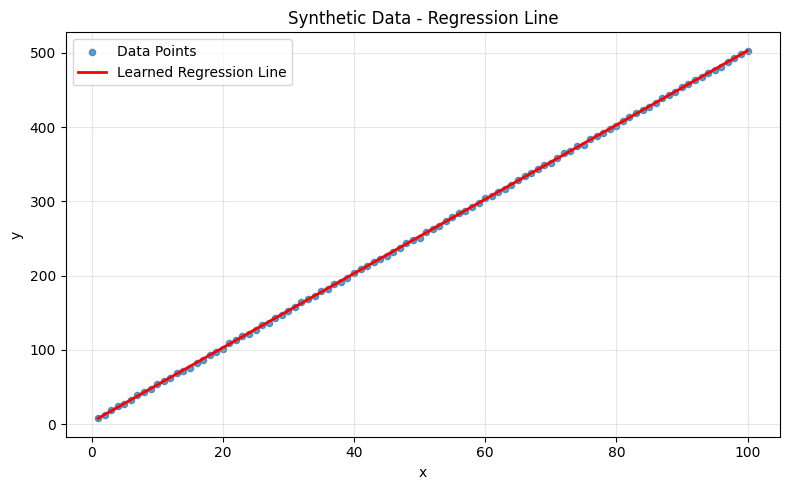

In [48]:
# ============================================
# SYNTHETIC - REGRESSION LINE
# ============================================

plot_regression_line(
    x_syn,
    y_syn,
    theta_syn,
    scale_params_syn,
    title="Synthetic Data - Regression Line"
)

In [49]:
# ============================================
# PART B - REAL DATA
# ============================================

from google.colab import files

uploaded = files.upload()

Saving data_01.csv to data_01 (1).csv


In [50]:
# ============================================
# LOAD REAL DATA
# ============================================

x_real, y_real = load_data(
    "data_01.csv",
    has_header=False
)

print("Real dataset loaded.")
print("Number of samples:", len(x_real))

print("\nFirst 10 x values:")
print(x_real[:10])

print("\nFirst 10 y values:")
print(y_real[:10])

Real dataset loaded.
Number of samples: 9568

First 10 x values:
[14.96 25.18  5.11 20.86 10.82 26.27 15.89  9.48 14.64 11.74]

First 10 y values:
[463.26 444.37 488.56 446.48 473.9  443.67 467.35 478.42 475.98 477.5 ]


In [51]:
# ============================================
# INSPECT REAL DATA
# ============================================

print("Number of samples:", len(x_real))

print("\nMinimum x:", np.min(x_real))
print("Maximum x:", np.max(x_real))

print("\nMinimum y:", np.min(y_real))
print("Maximum y:", np.max(y_real))

print("\nMissing x values:", np.isnan(x_real).sum())
print("Missing y values:", np.isnan(y_real).sum())

Number of samples: 9568

Minimum x: 1.81
Maximum x: 37.11

Minimum y: 420.26
Maximum y: 495.76

Missing x values: 0
Missing y values: 0


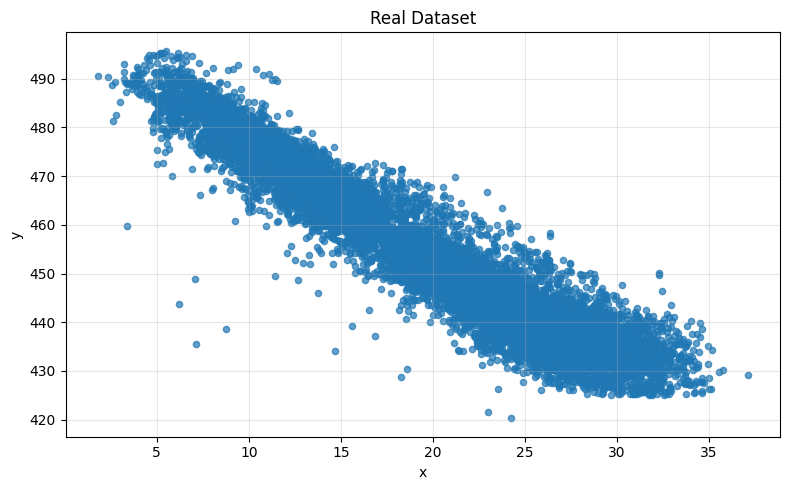

In [52]:
# ============================================
# PLOT REAL DATA
# ============================================

plot_data(
    x_real,
    y_real,
    title="Real Dataset"
)

In [59]:
# ============================================
# REAL DATA - WITHOUT FEATURE SCALING
# ============================================

X_real_raw, y_real_raw, params_real_raw = process_data(
    x_real,
    y_real,
    feature_scaling=False
)

learning_rates_real = [
    0.000001,
    0.00001,
    0.0001,
    0.001,
    0.002,
    0.01
]

print("Learning-rate experiment:")
print()

for lr in learning_rates_real:

    theta_test, cost_test = train(
        X_real_raw,
        y_real_raw,
        learning_rate=lr,
        iterations=5000
    )

    final_cost = cost_test[-1]

    print(
        f"Learning rate = {lr:<10} "
        f"Final cost = {final_cost:.6f}"
    )

Learning-rate experiment:

Learning rate = 1e-06      Final cost = 16520.249503
Learning rate = 1e-05      Final cost = 15296.261851
Learning rate = 0.0001     Final cost = 13664.391109
Learning rate = 0.001      Final cost = 4426.783012
Learning rate = 0.002      Final cost = 1272.479776


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_2909/3666378839.py:21: RuntimeWarning: overflow encountered in square
  cost = (1 / (2 * m)) * np.sum(errors ** 2)
/tmp/ipykernel_2909/1230421526.py:39: RuntimeWarning: invalid value encountered in subtract
  theta = theta - learning_rate * gradient


Learning rate = 0.01       Final cost = nan


In [54]:
# ============================================
# REAL DATA - FEATURE SCALING
# ============================================

X_real, y_real, scale_params_real = process_data(
    x_real,
    y_real,
    feature_scaling=True
)

print("Real data processed with feature scaling.")

print("\nMean of x:")
print(scale_params_real["mean"])

print("\nStandard deviation of x:")
print(scale_params_real["std"])

print("\nFirst 5 rows of X:")
print(X_real[:5])

Real data processed with feature scaling.

Mean of x:
19.65123118729097

Standard deviation of x:
7.452083771628027

First 5 rows of X:
[[ 1.         -0.62951938]
 [ 1.          0.74190911]
 [ 1.         -1.95129733]
 [ 1.          0.16220548]
 [ 1.         -1.18506869]]


In [55]:
# ============================================
# TRAIN REAL MODEL
# ============================================

theta_real, cost_history_real = train(
    X_real,
    y_real,
    learning_rate=0.01,
    iterations=1000
)

print("Training completed.")

Training completed.


In [56]:
# ============================================
# EVALUATE REAL MODEL
# ============================================

predictions_real, final_cost_real = evaluate(
    X_real,
    y_real,
    theta_real
)

print_parameters(
    theta_real,
    scale_params_real
)

Final Cost = 14.716044
LEARNED MODEL PARAMETERS
theta_0 = 454.345394
theta_1 = -16.180160

Original x scale:
Intercept = 497.012662
Slope     = -2.171226

Original-scale equation:
y_hat = 497.012662 + (-2.171226)x


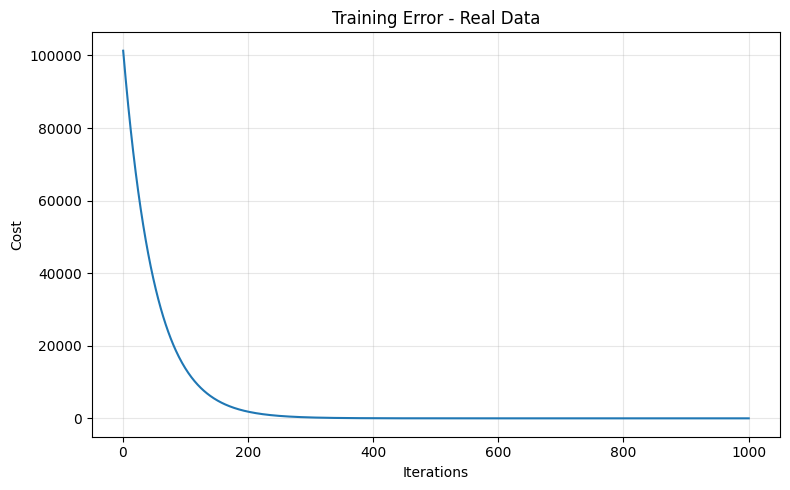

In [57]:
# ============================================
# REAL DATA - TRAINING ERROR
# ============================================

plot_cost_history(
    cost_history_real,
    title="Training Error - Real Data"
)

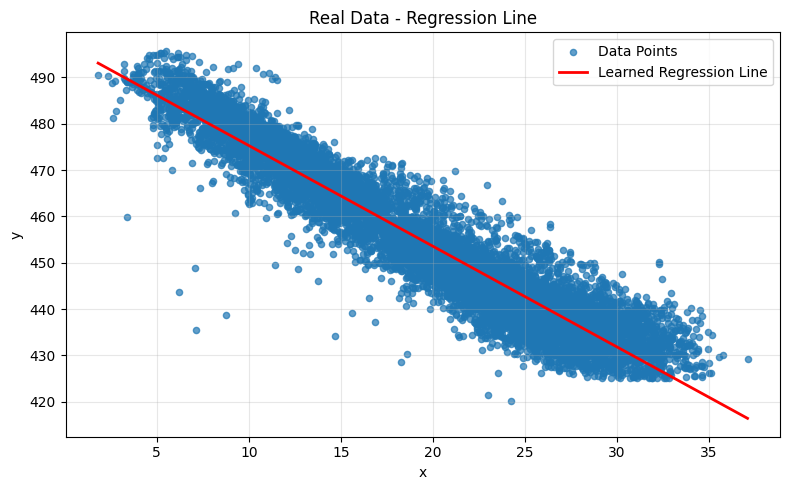

In [58]:
# ============================================
# REAL DATA - REGRESSION LINE
# ============================================

plot_regression_line(
    x_real,
    y_real,
    theta_real,
    scale_params_real,
    title="Real Data - Regression Line"
)